<a href="https://colab.research.google.com/github/gopaps/MachineLearning/blob/main/TUGAS%20PERBAIKAN/Chapter_3_Perbaikan_Anda_Figo_Haq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 3
membahas berbagai algoritma unsupervised learning yang digunakan untuk analisis data eksplorasi dan preprocessing. Algoritma-ini seperti PCA (Principal Component Analysis), t-SNE (t-Distributed Stochastic Neighbor Embedding), serta metode clustering seperti K-Means dan Agglomerative Clustering membantu kita memahami struktur data yang kompleks. Dengan melakukan reduksi dimensi, kita dapat merepresentasikan data dalam bentuk yang lebih sederhana tanpa kehilangan informasi penting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import torch

In [2]:
# Periksa apakah GPU tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU tersedia. Menggunakan:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU tidak tersedia. Menggunakan CPU.")

GPU tersedia. Menggunakan: Tesla T4


In [3]:
# Dataset Digits untuk eksplorasi
digits = load_digits()
X, y = digits.data, digits.target

# Konversi data menjadi tensor torch untuk potensi penggunaan GPU
X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
y_tensor = torch.tensor(y, dtype=torch.long, device=device)

# Reduksi Dimensi dengan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"Rasio Variansi PCA: {pca.explained_variance_ratio_}")

Rasio Variansi PCA: [0.14890594 0.13618771]


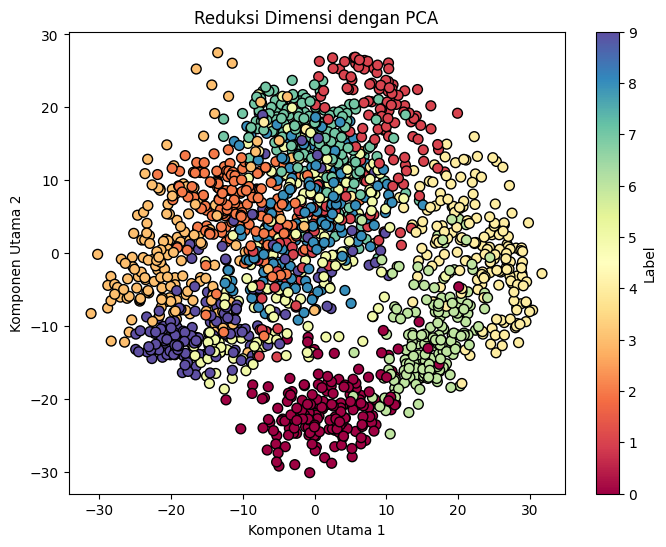

In [4]:
# Visualisasi hasil PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Spectral', edgecolor='k', s=50)
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.title('Reduksi Dimensi dengan PCA')
plt.colorbar(label='Label')
plt.show()

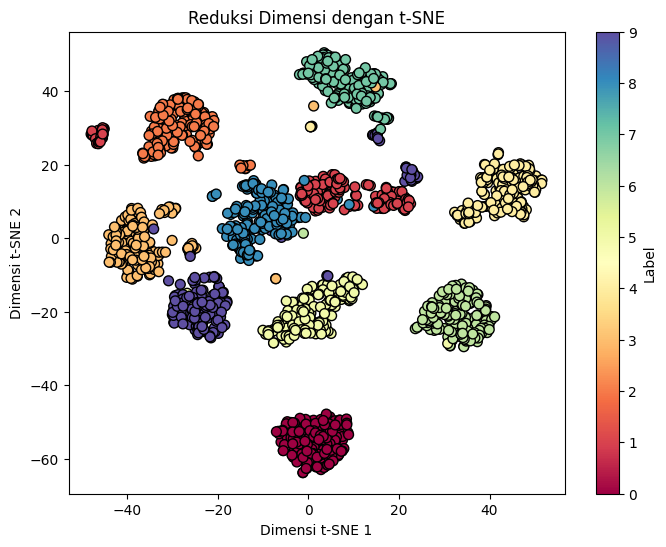

In [5]:
# Reduksi Dimensi dengan t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Visualisasi hasil t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='Spectral', edgecolor='k', s=50)
plt.xlabel('Dimensi t-SNE 1')
plt.ylabel('Dimensi t-SNE 2')
plt.title('Reduksi Dimensi dengan t-SNE')
plt.colorbar(label='Label')
plt.show()


In [6]:
# Clustering dengan K-Means
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
silhouette_kmeans = silhouette_score(X, kmeans_labels)
print(f"Silhouette Score K-Means: {silhouette_kmeans:.2f}")


Silhouette Score K-Means: 0.18


Silhouette Score Agglomerative Clustering: 0.18


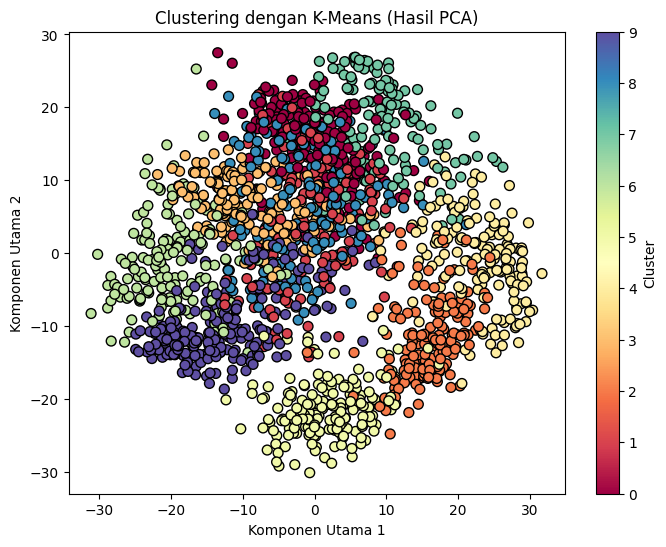

In [7]:
# Clustering dengan Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=10)
agglo_labels = agglo.fit_predict(X)
silhouette_agglo = silhouette_score(X, agglo_labels)
print(f"Silhouette Score Agglomerative Clustering: {silhouette_agglo:.2f}")

# Visualisasi hasil K-Means
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Spectral', edgecolor='k', s=50)
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.title('Clustering dengan K-Means (Hasil PCA)')
plt.colorbar(label='Cluster')
plt.show()

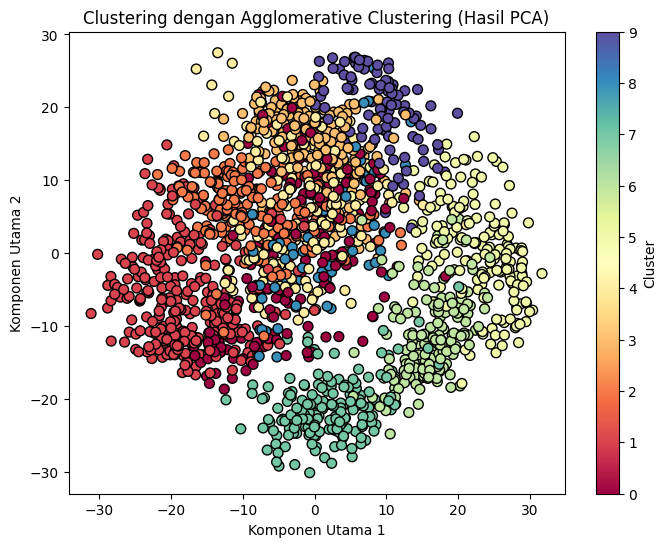

In [8]:
# Visualisasi hasil Agglomerative Clustering
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='Spectral', edgecolor='k', s=50)
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.title('Clustering dengan Agglomerative Clustering (Hasil PCA)')
plt.colorbar(label='Cluster')
plt.show()


PCA digunakan untuk mengidentifikasi komponen utama yang berkontribusi pada variasi dalam data, memungkinkan visualisasi data dalam dua dimensi. Selain itu, t-SNE memberikan representasi yang lebih baik dalam mengungkapkan hubungan non-linear antar data. Untuk analisis klaster, K-Means dan Agglomerative Clustering mengelompokkan data ke dalam cluster berdasarkan pola kemiripan, dengan evaluasi kualitas clustering menggunakan metrik Silhouette Score.

Dengan memanfaatkan metode ini, kita dapat memperoleh wawasan yang lebih baik tentang data, terutama ketika tidak ada informasi supervisi. Eksperimen dengan dataset bawaan seperti digits mempermudah dalam memahami bagaimana algoritma ini bekerja, baik untuk reduksi dimensi maupun pembentukan klaster. Hal ini menjadi langkah penting dalam pipeline machine learning, baik untuk eksplorasi awal maupun untuk mempersiapkan data bagi model supervised learning.